In [1]:
# 闻喜8760数据处理 

In [2]:
## 遍历文件夹，删除每个文件前13行数据，然后合并到一个Dataframe

In [3]:
import pandas as pd
import os

# 定义文件夹路径
folder_path = 'D:/工作/特变电工/08交易/疆外项目/闻喜项目/8760电量数据/光电技术部/闻喜8760数据/地块数据'

# 创建一个空的DataFrame用于存储合并后的数据
combined_df = pd.DataFrame()

# 遍历文件夹中的所有文件
for filename in os.listdir(folder_path):
    file_path = os.path.join(folder_path, filename)
    
    # 确保只处理文件（如果有子文件夹则跳过）
    if os.path.isfile(file_path):
        # 读取文件并跳过前13行，第一列不是列名
        df = pd.read_csv(file_path, skiprows=13,encoding='ISO-8859-1',header=None)
        
        # 将当前文件的数据追加到合并的DataFrame中
        combined_df = pd.concat([combined_df, df], ignore_index=True)

# 显示合并后的DataFrame
print(combined_df)


                                    0
0      01/01/90 00:00;0;0;0;-19.492;1
1      01/01/90 01:00;0;0;0;-19.492;1
2      01/01/90 02:00;0;0;0;-19.492;1
3      01/01/90 03:00;0;0;0;-19.492;1
4      01/01/90 04:00;0;0;0;-19.492;1
...                               ...
87595   31/12/90 19:00;0;0;0;-36.51;1
87596   31/12/90 20:00;0;0;0;-36.51;1
87597   31/12/90 21:00;0;0;0;-36.51;1
87598   31/12/90 22:00;0;0;0;-36.51;1
87599   31/12/90 23:00;0;0;0;-36.51;1

[87600 rows x 1 columns]


In [4]:
# 数据分列
split_df = combined_df[0].str.split(';', expand=True)


In [5]:
filtered_df=split_df[[0, 4]]
# 将第一列转换为 datetime 类型并设置为索引
filtered_df[0] = pd.to_datetime(filtered_df[0])  # 转换为 datetime
filtered_df.set_index(0, inplace=True)  # 设置为索引
filtered_df.columns=['PVgeneration']

C:\Users\96498\AppData\Local\Temp\ipykernel_33648\540891515.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df[0] = pd.to_datetime(filtered_df[0])  # 转换为 datetime


In [6]:
filtered_df

,PVgeneration
0,
1990-01-01 00:00:00,-19.492
1990-01-01 01:00:00,-19.492
1990-01-01 02:00:00,-19.492
1990-01-01 03:00:00,-19.492
1990-01-01 04:00:00,-19.492
...,...
1990-12-31 19:00:00,-36.51
1990-12-31 20:00:00,-36.51
1990-12-31 21:00:00,-36.51


In [7]:
# 按照时间索引进行分组，并求和发电量
filtered_df['PVgeneration']=pd.to_numeric(filtered_df['PVgeneration'], errors='coerce')  # 转换为 float
# 将表中的负值替换为 0
filtered_df = filtered_df.clip(lower=0)
grouped_df = filtered_df.resample('H').sum()  # 按小时分组并求和
grouped_df

C:\Users\96498\AppData\Local\Temp\ipykernel_33648\3919810540.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['PVgeneration']=pd.to_numeric(filtered_df['PVgeneration'], errors='coerce')  # 转换为 float


,PVgeneration
0,
1990-01-01 00:00:00,0.0
1990-01-01 01:00:00,0.0
1990-01-01 02:00:00,0.0
1990-01-01 03:00:00,0.0
1990-01-01 04:00:00,0.0
...,...
1990-12-31 19:00:00,0.0
1990-12-31 20:00:00,0.0
1990-12-31 21:00:00,0.0


In [8]:
result_df = grouped_df.groupby([grouped_df.index.month, grouped_df.index.hour]).sum()
result_df

# 或者，如果你已经知道索引是多级的，可以使用以下方法：
result_df = result_df.rename_axis(index=['month', 'hour'])
result_df

PVgeneration
month hour              
1     0              0.0
      1              0.0
      2              0.0
      3              0.0
      4              0.0
...                  ...
12    19             0.0
      20             0.0
      21             0.0
      22             0.0
      23             0.0

[288 rows x 1 columns]

In [8]:
result_df = grouped_df.groupby([grouped_df.index.month, grouped_df.index.hour]).sum()
result_df

# 或者，如果你已经知道索引是多级的，可以使用以下方法：
result_df = result_df.rename_axis(index=['month', 'hour'])
result_df

PVgeneration
month hour              
1     0              0.0
      1              0.0
      2              0.0
      3              0.0
      4              0.0
...                  ...
12    19             0.0
      20             0.0
      21             0.0
      22             0.0
      23             0.0

[288 rows x 1 columns]

In [9]:
# 使用 pivot_table 创建透视表
# result_df.columns = result_df.columns.str.strip()
pivot_table = result_df.pivot_table(index='month', columns='hour', values='PVgeneration', fill_value=0)
pivot_table

# 单位转换，将kWh转换为MWh
pivot_table=pivot_table/1000
pivot_table

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
month,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,3.092599,19.318197,91.403054,630.075042,1126.172454,...,977.548974,571.134978,225.970073,24.612581,4.872326,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,6.423353,46.240947,251.928054,696.885135,1159.962030,...,1250.109290,831.355390,379.161505,42.352388,5.992096,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,5.101487,70.442345,399.724594,953.377750,1399.161240,...,1420.559204,992.572125,443.373535,115.665549,0.987187,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,8.842307,191.037384,573.279206,1090.133088,1477.118357,...,1490.896920,1040.658580,530.337228,197.761344,8.938360,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,57.593501,260.224706,645.012183,1145.299363,1535.791260,...,1414.108910,1071.904236,564.638997,231.233145,22.656952,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,60.648007,224.797343,552.399861,1026.400100,1385.972303,...,1203.077940,868.707084,455.420431,198.561603,52.127023,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,18.640058,188.498630,523.435054,964.021170,1349.972518,...,1285.619003,938.993520,520.341278,238.559899,51.951624,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,3.730077,125.116945,459.579851,889.100938,1283.772720,...,1259.665490,877.151011,477.647629,183.691662,7.642858,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,2.672474,98.732537,449.523914,873.737545,1283.287100,...,1168.034830,803.035828,402.868276,75.954038,5.356572,0.0,0.0,0.0,0.0,0.0


In [10]:
pivot_table.to_clipboard()

<Axes: xlabel='hour'>

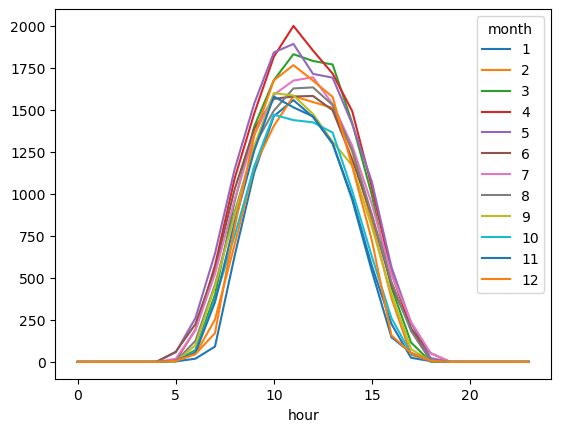

In [12]:
pivot_table.transpose().plot()